<a href="https://colab.research.google.com/github/DuaIlyas24/energy-consumption-forecasting/blob/main/task3_energy_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
!pip install prophet xgboost statsmodels


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor


In [52]:
import urllib.request
import zipfile

# 1️⃣ Download the ZIP file
zip_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"
zip_file = "household_power_consumption.zip"

print("Downloading dataset…")
urllib.request.urlretrieve(zip_url, zip_file)
print("Download complete!")

# 2️⃣ Extract the ZIP
with zipfile.ZipFile(zip_file, "r") as z:
    z.extractall()

print("Extraction complete!")

# The file inside ZIP should be:
# -> household_power_consumption.txt



Download complete!
Extraction complete!


In [53]:
import pandas as pd

df = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    parse_dates={"Datetime": ["Date", "Time"]},
    infer_datetime_format=True,
    low_memory=False,
    na_values=["?"]
)

# Convert relevant columns to numeric
numeric_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

df = df.set_index("Datetime")

df.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [54]:
# Check for missing values
print("Missing values per column:")
print(df.isna().sum())

# Fill missing values (simple forward fill)
df.fillna(method='ffill', inplace=True)

# Resample to hourly average for smoother forecasting
df_hourly = df.resample('H').mean()

df_hourly.head()


Missing values per column:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


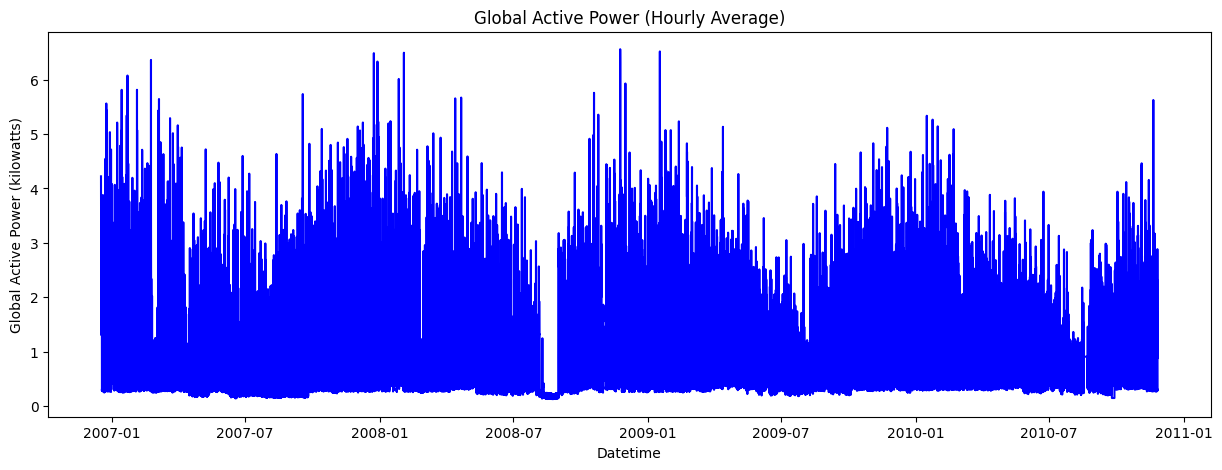

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df_hourly.index, df_hourly['Global_active_power'], color='blue')
plt.title("Global Active Power (Hourly Average)")
plt.xlabel("Datetime")
plt.ylabel("Global Active Power (kilowatts)")
plt.show()


In [56]:
df_hourly['hour'] = df_hourly.index.hour
df_hourly['day_of_week'] = df_hourly.index.dayofweek
df_hourly['month'] = df_hourly.index.month
df_hourly['weekend'] = (df_hourly['day_of_week'] >= 5).astype(int)

df_hourly.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,month,weekend
Datetime,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,17,5,12,1
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,18,5,12,1
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,19,5,12,1
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,20,5,12,1
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,21,5,12,1


In [58]:
# Split data (last 7 days for testing)
train = df_hourly.iloc[:-24*7]
test = df_hourly.iloc[-24*7:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)



Train shape: (34421, 11)
Test shape: (168, 11)


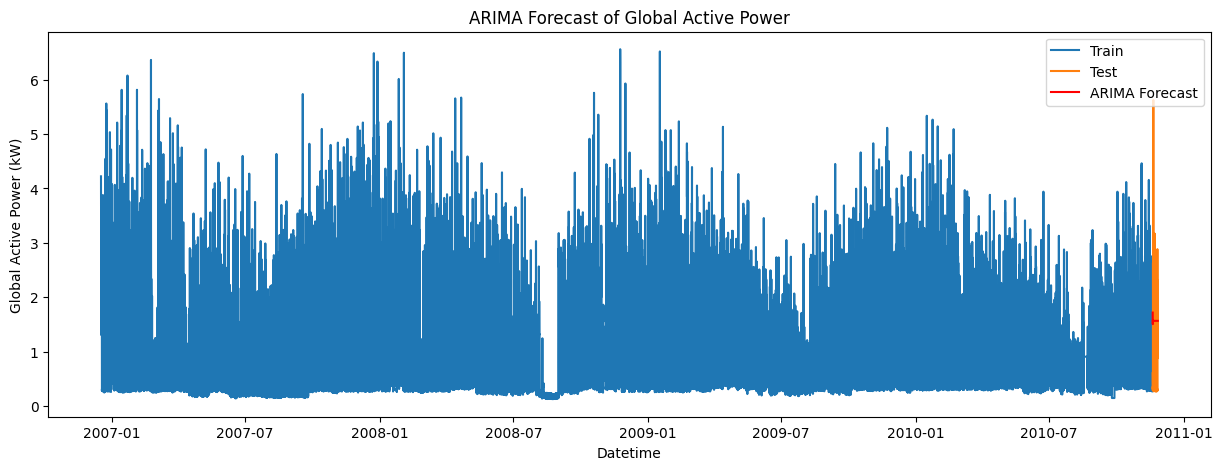

In [59]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

# Fit ARIMA model (you can tune order)
arima_model = ARIMA(train['Global_active_power'], order=(5,1,0))
arima_result = arima_model.fit()

# Forecast for test period
arima_forecast = arima_result.forecast(steps=len(test))

# Plot
plt.figure(figsize=(15,5))
plt.plot(train.index, train['Global_active_power'], label='Train')
plt.plot(test.index, test['Global_active_power'], label='Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast', color='red')
plt.title("ARIMA Forecast of Global Active Power")
plt.xlabel("Datetime")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.show()


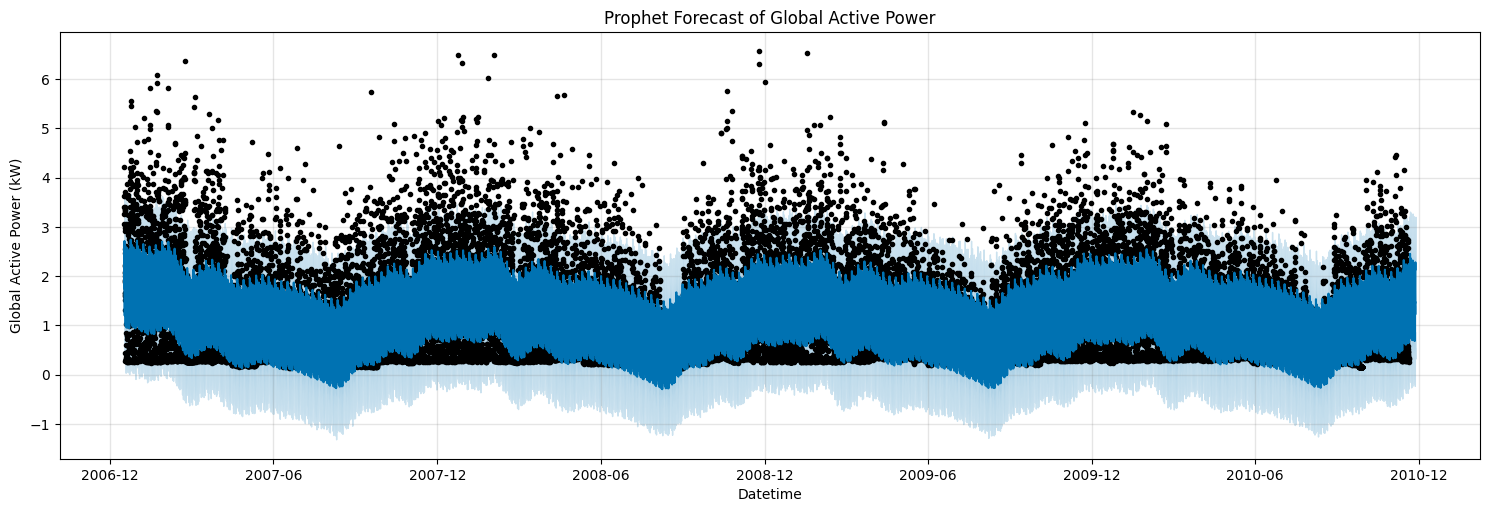

In [60]:
from prophet import Prophet
prophet_df = train[['Global_active_power']].reset_index()
prophet_df.rename(columns={'Datetime':'ds', 'Global_active_power':'y'}, inplace=True)

# Fit Prophet
prophet_model = Prophet(daily_seasonality=True, weekly_seasonality=True)
prophet_model.fit(prophet_df)

# Create future dataframe
future = prophet_model.make_future_dataframe(periods=len(test), freq='H')
forecast = prophet_model.predict(future)

# Plot
prophet_model.plot(forecast, figsize=(15,5))
plt.title("Prophet Forecast of Global Active Power")
plt.xlabel("Datetime")
plt.ylabel("Global Active Power (kW)")
plt.show()


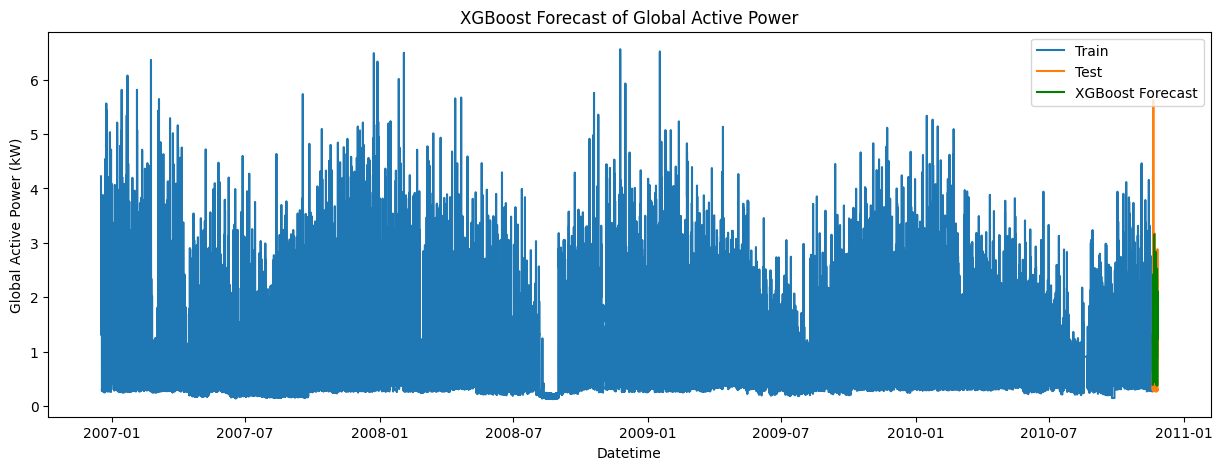

XGBoost MAE: 0.48565354707524894
XGBoost RMSE: 0.7082440753092117


In [61]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Features and target
features = ['hour','day_of_week','month','weekend']
X_train = train[features]
y_train = train['Global_active_power']
X_test = test[features]
y_test = test['Global_active_power']

# Fit XGBoost
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

# Forecast
xgb_pred = xgb_model.predict(X_test)

# Plot
plt.figure(figsize=(15,5))
plt.plot(train.index, y_train, label='Train')
plt.plot(test.index, y_test, label='Test')
plt.plot(test.index, xgb_pred, label='XGBoost Forecast', color='green')
plt.title("XGBoost Forecast of Global Active Power")
plt.xlabel("Datetime")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.show()

# Print MAE and RMSE
print("XGBoost MAE:", mean_absolute_error(y_test, xgb_pred))
print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))


In [63]:
# =========================
# Task 3 Completed
# =========================

print("Task 3: Energy Consumption Time Series Forecasting Completed Successfully!")
print(" Visualized forecasts from ARIMA, Prophet, and XGBoost models.")
print("Evaluation metrics are displayed for XGBoost.Compare results for other models visually.")


Task 3: Energy Consumption Time Series Forecasting Completed Successfully!
 Visualized forecasts from ARIMA, Prophet, and XGBoost models.
Evaluation metrics are displayed for XGBoost.Compare results for other models visually.
